# ROI Annotator

Temporary notebook to build `dataset/rois/<image_basename>.json` for the active drawing area of each page.

This first version records one rectangle per page in original image pixel coordinates. It uses the COCO image list from `dataset/annotations/annotations.json` and reads PNGs from `dataset/images/raw/`.

## How To Use

1. Run the setup and helper cells.
2. Run the annotation loop cell.
3. For each OpenCV window, drag the active drawing rectangle.
4. Press Enter or Space to accept the selection. Press `c` to cancel and retry/skip from the notebook prompt.
5. Run the review and validation cells when done.

The notebook writes each ROI immediately, so it is safe to stop and resume later.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    while current.parent != current:
        if (current / "CLAUDE.md").exists():
            return current
        current = current.parent
    raise RuntimeError(f"Could not find repo root from {start or Path.cwd()}")


REPO_ROOT = find_repo_root()
COCO_PATH = REPO_ROOT / "dataset" / "annotations" / "annotations.json"
IMAGES_DIR = REPO_ROOT / "dataset" / "images" / "raw"
ROIS_DIR = REPO_ROOT / "dataset" / "rois"

# Keep OpenCV windows manageable on laptop screens. Coordinates are scaled back
# to the original image before saving.
DISPLAY_MAX_DIM = 1400

with COCO_PATH.open("r", encoding="utf-8") as f:
    coco = json.load(f)

images = sorted(coco["images"], key=lambda item: item["id"])

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"Loaded {len(images)} images from {COCO_PATH.relative_to(REPO_ROOT)}")
print(f"ROIs will be written to {ROIS_DIR.relative_to(REPO_ROOT)}")


REPO_ROOT: C:\Users\Windows\Documents\Avolve\PoCs\object-detection-ii-final
Loaded 10 images from dataset\annotations\annotations.json
ROIs will be written to dataset\rois


In [2]:
def image_basename(image_info: dict[str, Any]) -> str:
    return Path(image_info["file_name"]).stem


def image_path(image_info: dict[str, Any]) -> Path:
    return IMAGES_DIR / image_info["file_name"]


def roi_path(image_info: dict[str, Any]) -> Path:
    return ROIS_DIR / f"{image_basename(image_info)}.json"


def rectangle_to_polygon(x: int, y: int, w: int, h: int) -> list[list[int]]:
    return [[x, y], [x + w, y], [x + w, y + h], [x, y + h]]


def build_roi_payload(image_info: dict[str, Any], bbox_xywh: tuple[int, int, int, int]) -> dict[str, Any]:
    x, y, w, h = bbox_xywh
    return {
        "image_id": int(image_info["id"]),
        "file_name": image_info["file_name"],
        "image_width": int(image_info["width"]),
        "image_height": int(image_info["height"]),
        "roi": {
            "type": "rectangle",
            "bbox_xywh": [int(x), int(y), int(w), int(h)],
            "polygon": rectangle_to_polygon(int(x), int(y), int(w), int(h)),
        },
    }


def load_roi(image_info: dict[str, Any]) -> dict[str, Any] | None:
    path = roi_path(image_info)
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def save_roi(image_info: dict[str, Any], bbox_xywh: tuple[int, int, int, int]) -> Path:
    ROIS_DIR.mkdir(parents=True, exist_ok=True)
    payload = build_roi_payload(image_info, bbox_xywh)
    path = roi_path(image_info)
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
        f.write("\n")
    return path


def validate_roi_payload(payload: dict[str, Any]) -> None:
    roi = payload["roi"]
    assert roi["type"] == "rectangle"
    x, y, w, h = roi["bbox_xywh"]
    image_width = payload["image_width"]
    image_height = payload["image_height"]
    assert w > 0 and h > 0, roi["bbox_xywh"]
    assert 0 <= x < image_width, roi["bbox_xywh"]
    assert 0 <= y < image_height, roi["bbox_xywh"]
    assert x + w <= image_width, roi["bbox_xywh"]
    assert y + h <= image_height, roi["bbox_xywh"]
    assert roi["polygon"] == rectangle_to_polygon(x, y, w, h)


In [3]:
def display_scale_for(image) -> float:
    height, width = image.shape[:2]
    return min(1.0, DISPLAY_MAX_DIM / max(width, height))


def draw_existing_roi(display_image, existing_roi: dict[str, Any] | None, scale: float) -> None:
    if existing_roi is None:
        return
    x, y, w, h = existing_roi["roi"]["bbox_xywh"]
    p1 = (round(x * scale), round(y * scale))
    p2 = (round((x + w) * scale), round((y + h) * scale))
    cv2.rectangle(display_image, p1, p2, (255, 0, 0), 2)


def select_roi_rectangle(image_info: dict[str, Any]) -> tuple[int, int, int, int] | None:
    path = image_path(image_info)
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)

    scale = display_scale_for(image)
    if scale < 1.0:
        display_image = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    else:
        display_image = image.copy()

    draw_existing_roi(display_image, load_roi(image_info), scale)
    title = f"ROI: {image_info['id']} - {image_info['file_name']}"
    print(f"Selecting ROI for {image_info['file_name']} at display scale {scale:.3f}")
    print("Drag rectangle, then press Enter/Space. Press c in the OpenCV window to cancel.")

    x, y, w, h = cv2.selectROI(title, display_image, showCrosshair=True, fromCenter=False)
    cv2.destroyWindow(title)

    if w == 0 or h == 0:
        return None

    inv_scale = 1.0 / scale
    x0 = max(0, round(x * inv_scale))
    y0 = max(0, round(y * inv_scale))
    x1 = min(int(image_info["width"]), round((x + w) * inv_scale))
    y1 = min(int(image_info["height"]), round((y + h) * inv_scale))
    return (x0, y0, x1 - x0, y1 - y0)


## Annotate ROIs

Adjust `START_INDEX` if you want to resume from a specific image in the sorted COCO list. Existing ROI files are skipped by default; change `OVERWRITE_EXISTING` to `True` if you want the notebook to ask before replacing them.


In [4]:
START_INDEX = 0
OVERWRITE_EXISTING = False

for idx, image_info in enumerate(images[START_INDEX:], start=START_INDEX):
    existing = load_roi(image_info)
    if existing is not None and not OVERWRITE_EXISTING:
        print(f"[{idx + 1}/{len(images)}] exists, skipping: {roi_path(image_info).relative_to(REPO_ROOT)}")
        continue

    if existing is not None and OVERWRITE_EXISTING:
        answer = input(f"ROI exists for {image_info['file_name']}. Overwrite? [y/N/q] ").strip().lower()
        if answer == "q":
            break
        if answer != "y":
            continue

    while True:
        print(f"\n[{idx + 1}/{len(images)}] {image_info['file_name']}")
        bbox = select_roi_rectangle(image_info)
        if bbox is None:
            answer = input("Selection cancelled. Retry, skip, or quit? [r/s/q] ").strip().lower()
            if answer in {"", "r"}:
                continue
            if answer == "q":
                raise KeyboardInterrupt("ROI annotation stopped by user")
            break

        path = save_roi(image_info, bbox)
        validate_roi_payload(load_roi(image_info))
        print(f"Saved {path.relative_to(REPO_ROOT)} bbox_xywh={bbox}")
        break

cv2.destroyAllWindows()



[1/10] 001_Fire_Sprinkler_Plan_page_001.png
Selecting ROI for 001_Fire_Sprinkler_Plan_page_001.png at display scale 0.456
Drag rectangle, then press Enter/Space. Press c in the OpenCV window to cancel.
Saved dataset\rois\001_Fire_Sprinkler_Plan_page_001.json bbox_xywh=(68, 125, 2043, 1075)

[2/10] 001_FP1_Fire_Sprinkler_Plan_page_001.png
Selecting ROI for 001_FP1_Fire_Sprinkler_Plan_page_001.png at display scale 0.456
Drag rectangle, then press Enter/Space. Press c in the OpenCV window to cancel.
Saved dataset\rois\001_FP1_Fire_Sprinkler_Plan_page_001.json bbox_xywh=(204, 132, 873, 851)

[3/10] 001_FP100_Fire_Sprinkler_Plan_page_001.png
Selecting ROI for 001_FP100_Fire_Sprinkler_Plan_page_001.png at display scale 0.456
Drag rectangle, then press Enter/Space. Press c in the OpenCV window to cancel.
Saved dataset\rois\001_FP100_Fire_Sprinkler_Plan_page_001.json bbox_xywh=(935, 434, 1768, 676)

[4/10] 001_Kay_Jewelers_-_fire_sprinkler_plan_page_001.png
Selecting ROI for 001_Kay_Jewelers_

## Review Saved ROIs

Run this cell after annotation to visually inspect the rectangles saved so far.


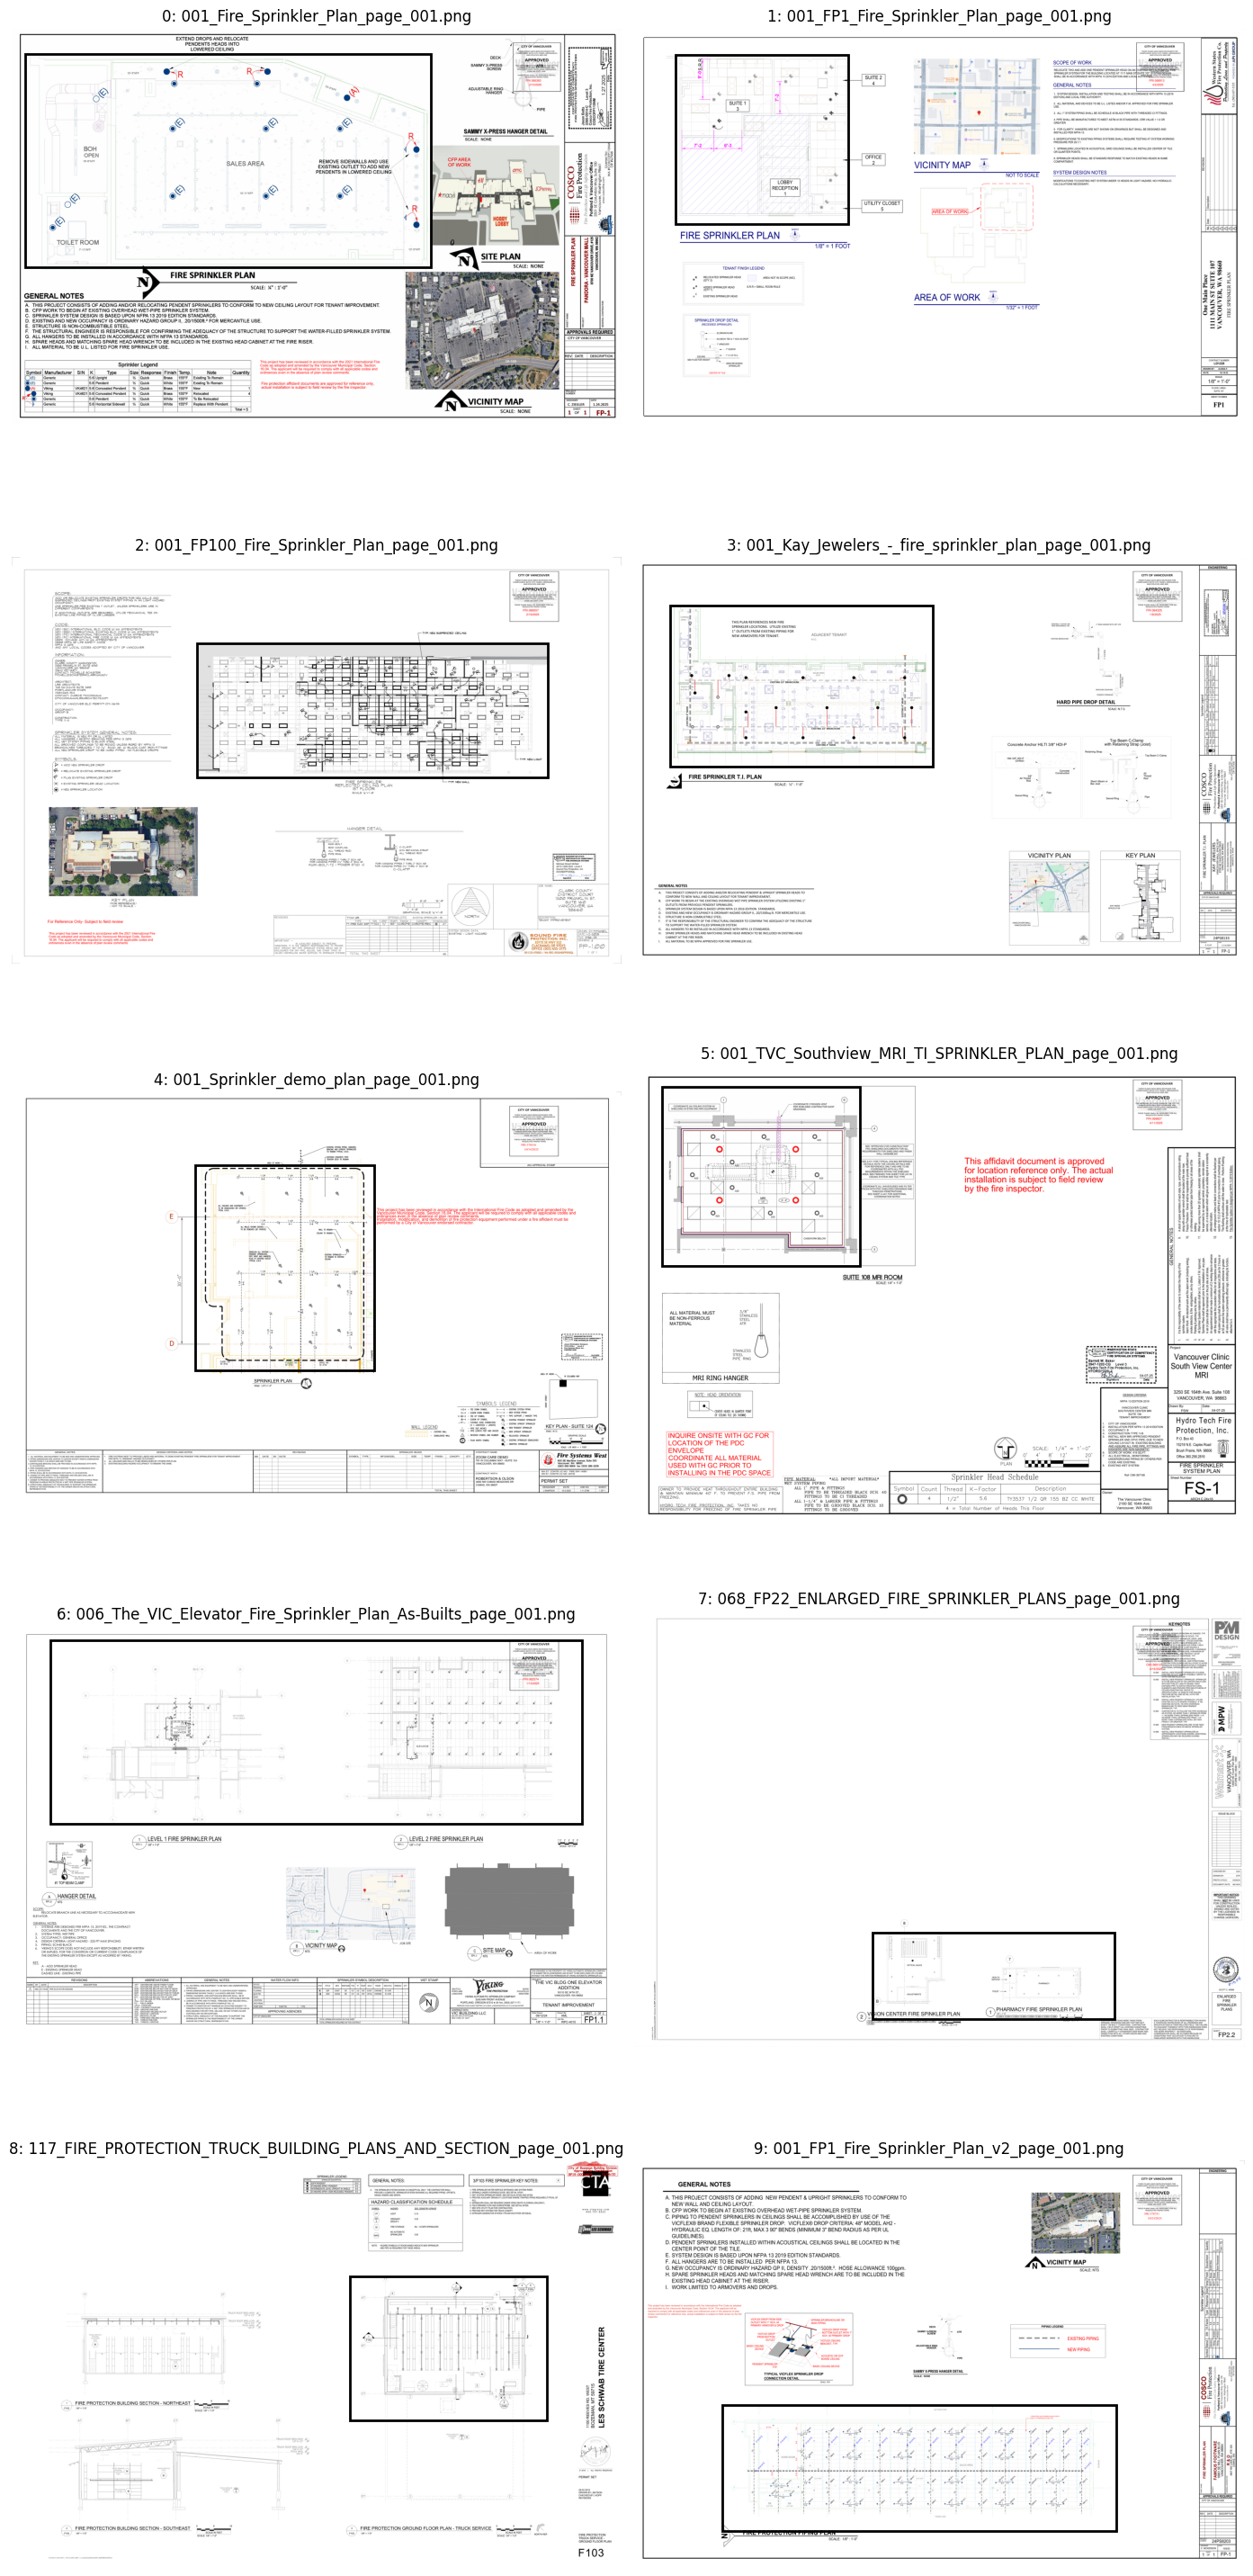

In [5]:
saved_items = [(image_info, load_roi(image_info)) for image_info in images]
saved_items = [(image_info, roi) for image_info, roi in saved_items if roi is not None]

if not saved_items:
    print("No ROI files found yet.")
else:
    cols = 2
    rows = (len(saved_items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 6 * rows), squeeze=False)

    for ax in axes.ravel():
        ax.axis("off")

    for ax, (image_info, roi) in zip(axes.ravel(), saved_items):
        image = cv2.imread(str(image_path(image_info)), cv2.IMREAD_COLOR)
        if image is None:
            ax.set_title(f"Missing image: {image_info['file_name']}")
            continue
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        x, y, w, h = roi["roi"]["bbox_xywh"]
        ax.imshow(image_rgb)
        rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
        ax.add_patch(rect)
        ax.set_title(f"{image_info['id']}: {image_info['file_name']}")
        ax.axis("off")

    plt.tight_layout()


## Validate ROI JSON Files

This checks that every saved ROI has the expected rectangle schema and stays inside the original image bounds.


In [6]:
errors: list[str] = []
saved_count = 0

for image_info in images:
    payload = load_roi(image_info)
    if payload is None:
        continue
    saved_count += 1
    try:
        assert payload["image_id"] == image_info["id"]
        assert payload["file_name"] == image_info["file_name"]
        assert payload["image_width"] == image_info["width"]
        assert payload["image_height"] == image_info["height"]
        validate_roi_payload(payload)
    except Exception as exc:
        errors.append(f"{roi_path(image_info).name}: {exc}")

print(f"Validated {saved_count}/{len(images)} saved ROI files.")
if errors:
    raise AssertionError("\n".join(errors))


Validated 10/10 saved ROI files.
